# Colab Session: ml-lab
Generated from colab-cli history log.

In [ ]:
# Bootstrap for Google Colab: make sure the project code (src/) is on disk.
# If you opened this notebook from GitHub, clone the repo; on a local machine,
# or a Colab session that already started from the repo, this is a no-op.
from pathlib import Path

content_clone = Path('/content/ML_lab_project')


def _has_src(root):
    return (root / 'src').is_dir()


root = next((c for c in [Path.cwd(), *Path.cwd().parents] if _has_src(c)), None)
if root is None and _has_src(content_clone):
    root = content_clone
if root is None and Path('/content').is_dir():
    import subprocess
    subprocess.run([
        'git', 'clone',
        'https://github.com/hellomoinul/diabetes-risk-prediction.git',
        str(content_clone),
    ], check=True)
    root = content_clone
if root is None:
    raise FileNotFoundError(
        'Could not locate this project on disk. Upload and unzip the repo '
        'archive, or open this notebook from a folder that contains src/.')

import sys
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f'Project root: {root}')

**Session Created**: 2026-10-02 13:36:26
- Endpoint: `m-s-kkb-usc1b0-3ngmqcu4ic2pa`
- Hardware: `NONE`

*File Operation*: `upload` on `/content/ML_lab_colab.zip`

*File Operation*: `upload` on `/content/unzip_remote.py`

In [1]:
import zipfile, pathlib
zipfile.ZipFile('/content/ML_lab_colab.zip').extractall('/content')
for p in pathlib.Path('/content/ML_lab_project').iterdir():
    if p.is_dir():
        print(p.name)
print("Extracted OK")

FileNotFoundError: [Errno 2] No such file or directory: '/content/ML_lab_colab.zip'

In [2]:
import sys
from pathlib import Path


def find_project_root() -> Path:
    """Locate the project root, i.e. the folder that contains ``src/``.

    Works unchanged on a local machine and on Google Colab: locally we
    walk up from the working directory, and on Colab we additionally
    search ``/content``, where uploaded files are placed.
    """
    candidates = [Path.cwd(), *Path.cwd().parents]
    content = Path("/content")
    if content.is_dir():
        candidates += [content, *sorted(p for p in content.iterdir() if p.is_dir())]
    for candidate in candidates:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError(
        "No folder containing 'src/' was found. On Google Colab, upload "
        "the project archive and unzip it before running this cell."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

FileNotFoundError: No folder containing 'src/' was found. On Google Colab, upload the project archive and unzip it before running this cell.

In [ ]:
# Installs only what is missing, so this is a no-op on a machine that
# already has the dependencies (e.g. after `pip install -r requirements.txt`).
import importlib.util
import subprocess
import sys

REQUIRED = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}
missing = [pkg for mod, pkg in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]
if missing:
    print(f"Installing: {', '.join(missing)}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                   check=True)
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [ ]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

import pandas as pd
from sklearn.feature_selection import f_classif
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from src import plots
from src.data import (
    RANDOM_STATE, TARGET,
    build_preprocessor, category_breakdown, class_balance, data_quality_report,
    drop_duplicates, duplicate_report, load_data, majority_baseline, make_splits,
    missing_value_report, summary_statistics,
)
from src.evaluation import (
    baseline_evaluation, baseline_reference_line, evaluate_pipeline,
    final_result_table, metrics_table,
)
from src.fetch_data import KAGGLE_URL, fetch
from src.models import (
    _cv, feature_importance, get_specs, imbalance_ratio, overfitting_check,
    stratified_subsample, tune_model,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

print(f"pandas           {pd.__version__}")
import sklearn
print(f"scikit-learn     {sklearn.__version__}")
print(f"random_state     {RANDOM_STATE}")
print(f"source           {KAGGLE_URL}")

pandas           2.2.3
scikit-learn     1.6.1
random_state     42
source           https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset


In [ ]:
raw = fetch()
raw.shape

Using existing data/diabetes_prediction_dataset.csv (100,000 rows)


(100000, 9)

In [ ]:
class_balance(raw)

,Diagnosis,Count,Percent,Ratio
0,Negative (no diabetes),91500,91.5,10.764706
1,Positive (diabetes),8500,8.5,10.764706


In [ ]:
summary_statistics(raw).round(2)

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.89,22.52,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.07,0.26,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.04,0.19,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.32,6.64,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.53,1.07,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.06,40.71,80.00,100.00,140.00,159.00,300.00


In [ ]:
missing_value_report(raw)

,Feature,NaN cells,'No Info' sentinel,Total missing
0,gender,0,0,0
1,age,0,0,0
2,hypertension,0,0,0
3,heart_disease,0,0,0
4,smoking_history,0,35816,35816
5,bmi,0,0,0
6,HbA1c_level,0,0,0
7,blood_glucose_level,0,0,0
8,diabetes,0,0,0


In [ ]:
duplicate_report(raw)

,Check,Count
0,Full-row duplicates,3854
1,Duplicates ignoring target,3945
2,Rows in a duplicate group,6939
3,Groups with conflicting labels,1


In [ ]:
df = drop_duplicates(raw)
removed = len(raw) - len(df)
print(f"Removed {removed:,} duplicate rows -> {len(df):,} rows")
print(f"Positive rate: {100 * df[TARGET].mean():.2f}% (was {100 * raw[TARGET].mean():.2f}%)")
df.head()

Removed 3,854 duplicate rows -> 96,146 rows
Positive rate: 8.82% (was 8.50%)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
category_breakdown(raw).query("Feature == 'smoking_history'")

,Feature,Value,Count,Diabetes %
6,smoking_history,former,9352,17.00
5,smoking_history,ever,4004,11.79
8,smoking_history,not current,6447,10.70
4,smoking_history,current,9286,10.21
7,smoking_history,never,35095,9.53
3,smoking_history,No Info,35816,4.06


In [ ]:
category_breakdown(raw).query("Feature != 'smoking_history'")

,Feature,Value,Count,Diabetes %
1,gender,Male,41430,9.75
0,gender,Female,58552,7.62
2,gender,Other,18,0.00
12,heart_disease,1,3942,32.14
11,heart_disease,0,96058,7.53
10,hypertension,1,7485,27.90
9,hypertension,0,92515,6.93


In [ ]:
data_quality_report(raw)

,Check,Rows,Percent of data
0,age below 18,17219,17.22
1,age below 1 year,911,0.91
2,age above 75,8387,8.39
3,bmi below 15,1476,1.48
4,bmi above 60,115,0.12
5,bmi == 0,0,0.00
6,HbA1c above 10,0,0.00
7,blood glucose below 70,0,0.00
8,gender == 'Other',18,0.02


In [ ]:
child = raw["age"] < 18
print(f"Patients under 18      : {int(child.sum()):,} "
      f"({100 * child.mean():.1f}% of the data)")
print(f"  ... of whom under 1 yr : {int((raw['age'] < 1).sum()):,}")
print(f"Positives among them    : {int(raw.loc[child, TARGET].sum()):,} "
      f"({100 * raw.loc[child, TARGET].mean():.2f}% vs "
      f"{100 * raw[TARGET].mean():.2f}% overall)")

print("\nSo in this dataset being a child is nearly equivalent to being "
      "negative.\nAge ranks 3rd in feature importance partly for that reason, "
      "not only because age is clinically real.")

Patients under 18      : 17,219 (17.2% of the data)
  ... of whom under 1 yr : 911
Positives among them    : 82 (0.48% vs 8.50% overall)

So in this dataset being a child is nearly equivalent to being negative.
Age ranks 3rd in feature importance partly for that reason, not only because age is clinically real.


(array([[<Axes: title={'center': 'age'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='age'>,
         <Axes: title={'center': 'hypertension'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='hypertension'>,
         <Axes: title={'center': 'heart_disease'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='heart_disease'>],
        [<Axes: title={'center': 'bmi'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='bmi'>,
         <Axes: title={'center': 'HbA1c_level'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='HbA1c_level'>,
         <Axes: title={'center': 'blood_glucose_level'}, xlabel='diabetes (0 = no, 1 = yes)', ylabel='blood_glucose_level'>]],
       dtype=object),
 PosixPath('/content/ML_lab_project/figures/01b_numeric_boxplots.png'))

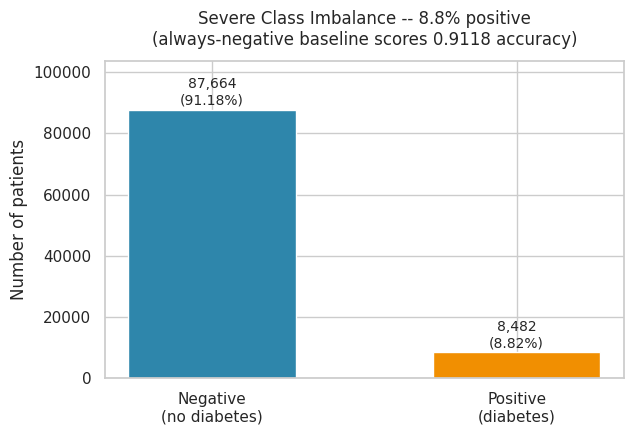

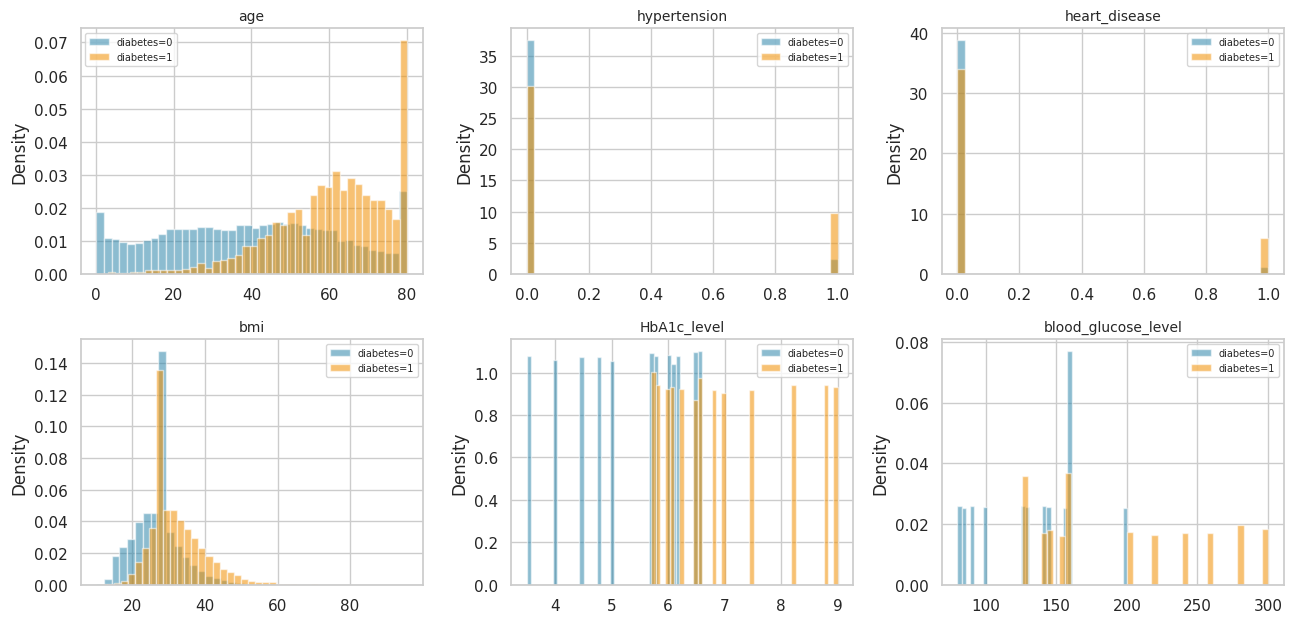

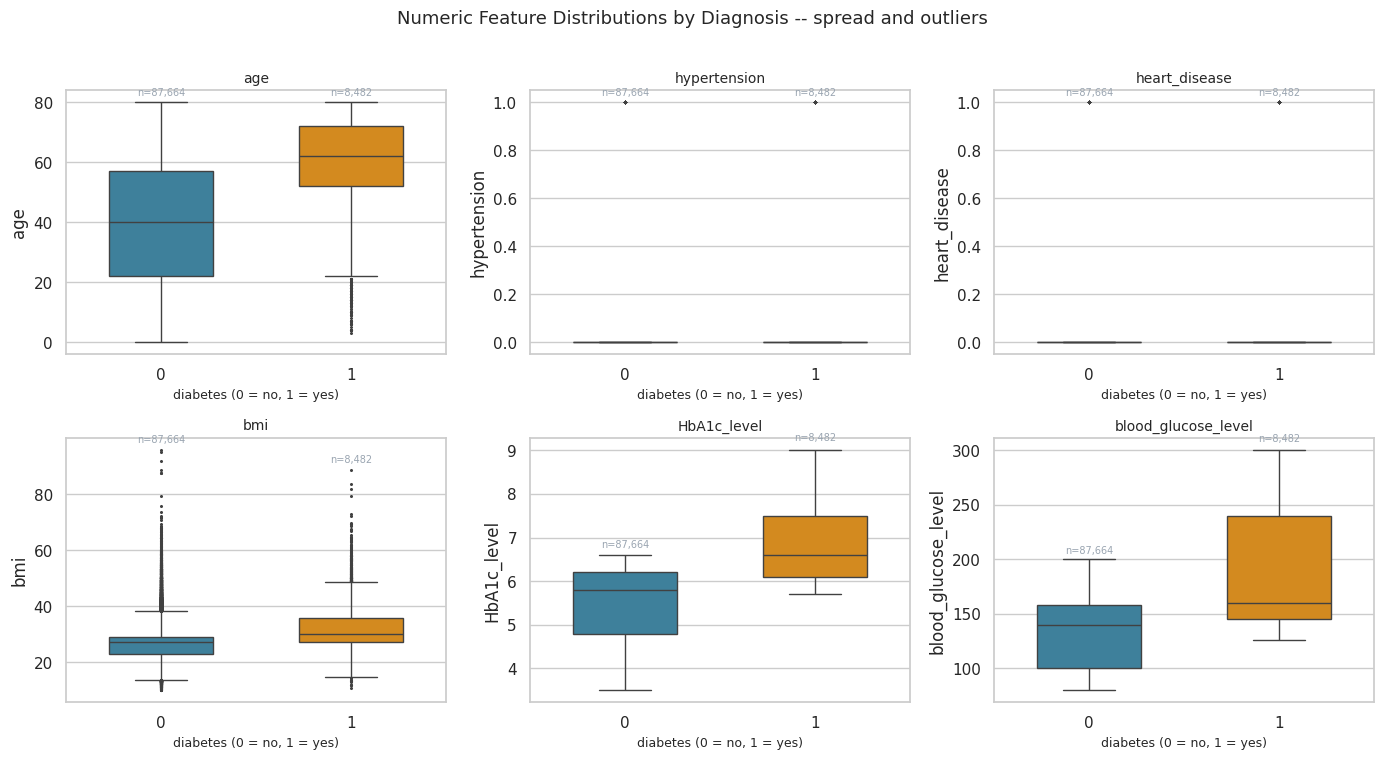

In [ ]:
plots.plot_class_balance(df)
plots.plot_numeric_distributions(df)
plots.plot_numeric_boxplots(df)

(<Axes: title={'center': "Missing Data: isnull() reports 0, but 35.8% of rows are\nencoded as the string 'No Info' in smoking_history"}, ylabel='Rows'>,
 PosixPath('/content/ML_lab_project/figures/05_missingness_sentinel.png'))

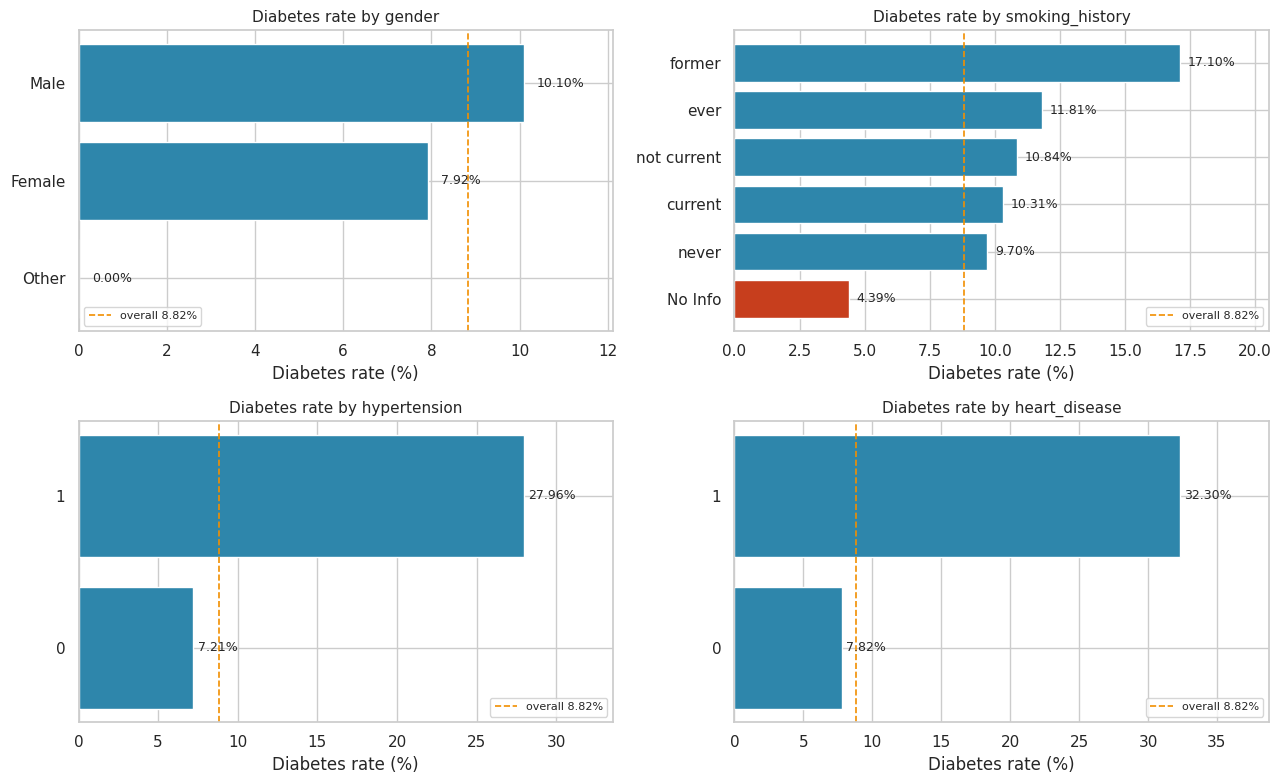

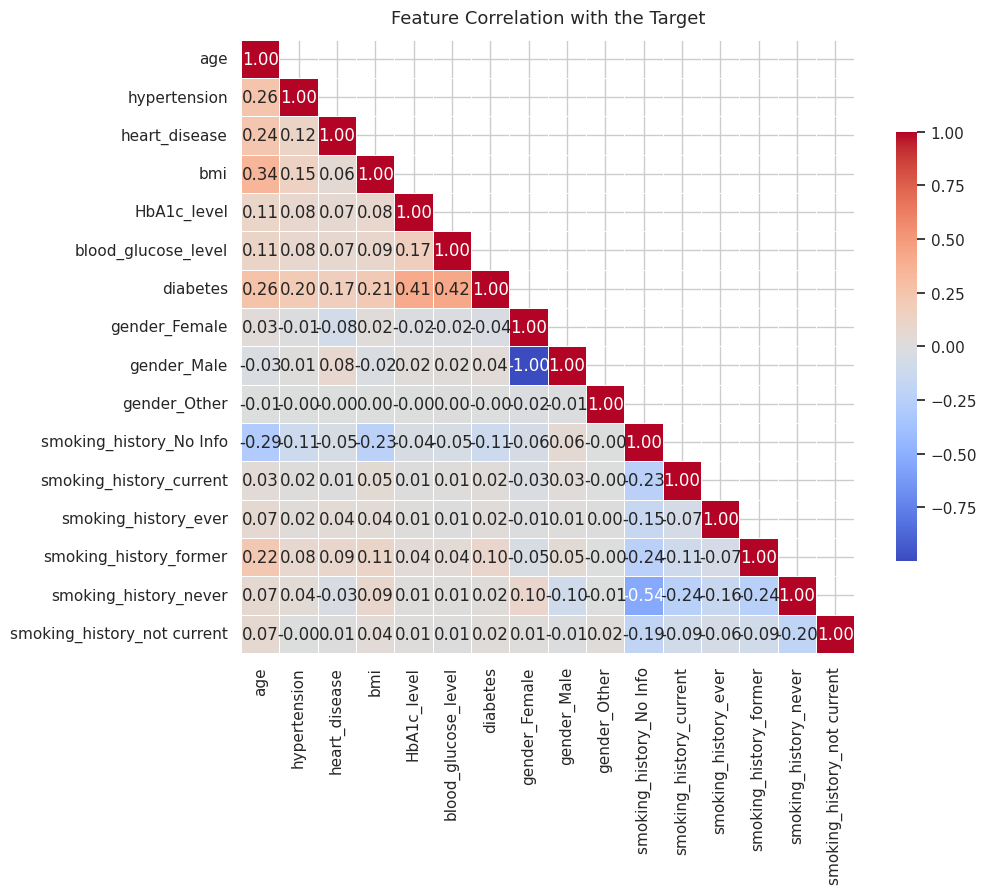

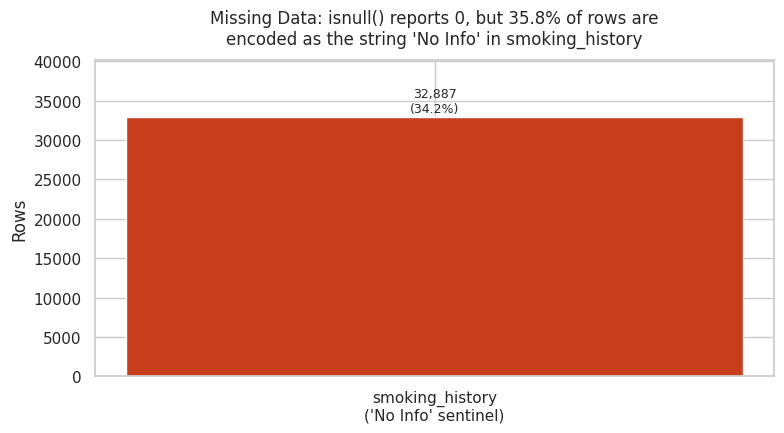

In [ ]:
plots.plot_category_diabetes_rates(df)
plots.plot_correlation_heatmap(df)
plots.plot_missingness(df)

In [ ]:
pre = build_preprocessor()
Xt = pre.fit_transform(df.drop(columns=[TARGET]), df[TARGET])
print(f"6 numeric + 3 gender + 6 smoking = {Xt.shape[1]} features, {Xt.shape[0]:,} rows")
print(list(pre.get_feature_names_out()))

6 numeric + 3 gender + 6 smoking = 15 features, 96,146 rows
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Female', 'gender_Male', 'gender_Other', 'smoking_history_No Info', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


In [ ]:
splits = make_splits(df)
for name, X, y in [
    ("train", splits.X_train, splits.y_train),
    ("val  ", splits.X_val, splits.y_val),
    ("test ", splits.X_test, splits.y_test),
]:
    print(f"{name}  {len(X):7,} rows   positive {int(y.sum()):5,}  ({100 * y.mean():.2f}%)")

print(f"\nMajority-class baseline accuracy: {majority_baseline(splits.y_test):.4f}")

train   67,302 rows   positive 5,937  (8.82%)
val     14,422 rows   positive 1,273  (8.83%)
test    14,422 rows   positive 1,272  (8.82%)

Majority-class baseline accuracy: 0.9118


In [ ]:
baseline_ev = baseline_evaluation("Majority Baseline", splits.y_test)
print(baseline_reference_line([baseline_ev]))
print(f"\nTP {baseline_ev.tp}  FP {baseline_ev.fp}  TN {baseline_ev.tn}  FN {baseline_ev.fn}")

Majority-class baseline (always predict 'no diabetes'): Accuracy 0.9118, Recall 0.0000, PR-AUC 0.0882

TP 0  FP 0  TN 13150  FN 1272


In [ ]:
cv = _cv()
ratio = imbalance_ratio(splits.y_train)
print(f"Negative-to-positive ratio in train: {ratio:.2f}")
print("Passed to XGBoost as scale_pos_weight, and to the scikit-learn")
print("models as class_weight='balanced'.")

Negative-to-positive ratio in train: 10.34
Passed to XGBoost as scale_pos_weight, and to the scikit-learn
models as class_weight='balanced'.


In [ ]:
encoded = pre.fit_transform(df.drop(columns=[TARGET]), df[TARGET])
names = list(pre.get_feature_names_out())
# The first six columns are the numeric block; the rest are one-hot columns.
f_stat, p_value = f_classif(encoded[:, :6], df[TARGET])
numeric_rank = (
    pd.DataFrame({
        "Feature": names[:6],
        "F statistic": f_stat,
        "p-value": p_value,
    })
    .sort_values("F statistic", ascending=False)
)
numeric_rank.round(4)

,Feature,F statistic,p-value
5,blood_glucose_level,21113.4892,0.0
4,HbA1c_level,19021.6540,0.0
0,age,7257.3560,0.0
3,bmi,4656.5453,0.0
1,hypertension,3829.2023,0.0
2,heart_disease,2885.9517,0.0


In [ ]:
cat_rank = (
    df.groupby("smoking_history")[TARGET].agg(["size", "mean"])
    .assign(**{"Diabetes %": lambda t: (100 * t["mean"]).round(2)})
    .sort_values("Diabetes %", ascending=False)
)
cat_rank[["size", "Diabetes %"]]

,size,Diabetes %
smoking_history,,
former,9299,17.10
ever,3998,11.81
not current,6367,10.84
current,9197,10.31
never,34398,9.70
No Info,32887,4.39


In [ ]:
overfit = pd.concat(
    [
        overfitting_check(
            "Decision Tree (unrestricted)",
            DecisionTreeClassifier(max_depth=None, min_samples_leaf=1,
                                   class_weight="balanced", random_state=RANDOM_STATE),
            splits.X_train, splits.y_train, cv=cv),
        overfitting_check(
            "XGBoost (deep, 2000 trees)",
            XGBClassifier(n_estimators=2000, max_depth=12, learning_rate=0.1,
                          eval_metric="logloss", verbosity=0, random_state=RANDOM_STATE),
            splits.X_train, splits.y_train, cv=cv),
    ],
    ignore_index=True,
)
overfit.round(4)

,Model,Train AUC,Validation AUC,Gap (over-fit)
0,Decision Tree (unrestricted),1.0,0.8504,0.1496
1,"XGBoost (deep, 2000 trees)",1.0,0.9658,0.0341


In [ ]:
SVM_SEARCH_ROWS = 20_000
specs = get_specs(scale_pos_weight=ratio)
fitted = {}

for name, spec in specs.items():
    search_X, search_y = splits.X_train, splits.y_train
    if name == "SVM":
        search_X, search_y = stratified_subsample(
            splits.X_train, splits.y_train, SVM_SEARCH_ROWS)
    fitted[name] = tune_model(spec, search_X, search_y, cv=cv)
    params = {k.replace("clf__", ""): v for k, v in fitted[name].best_params.items()}
    print(f"{name:22s} best CV ROC-AUC {fitted[name].best_cv_score:.4f}  {params}")

Logistic Regression    best CV ROC-AUC 0.9626  {'C': 0.01}


Decision Tree          best CV ROC-AUC 0.9740  {'max_depth': 8, 'min_samples_leaf': 50}


SVM                    best CV ROC-AUC 0.9609  {'C': 1.0}


XGBoost                best CV ROC-AUC 0.9796  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}


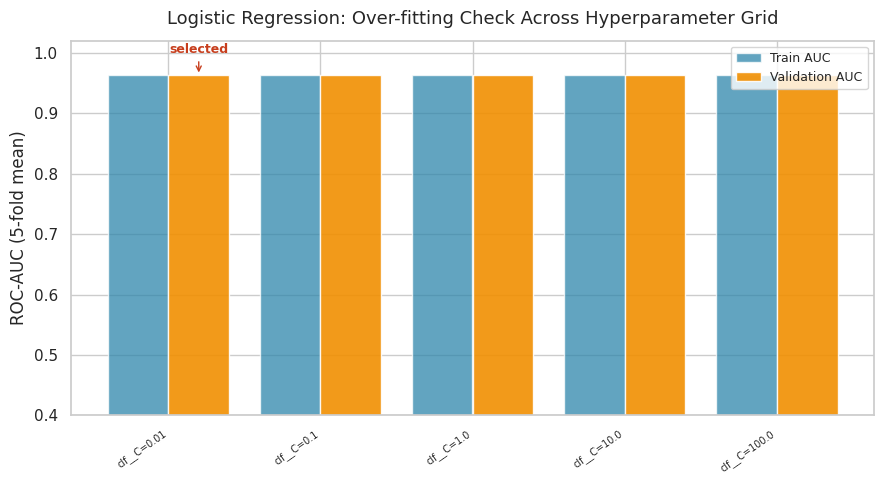

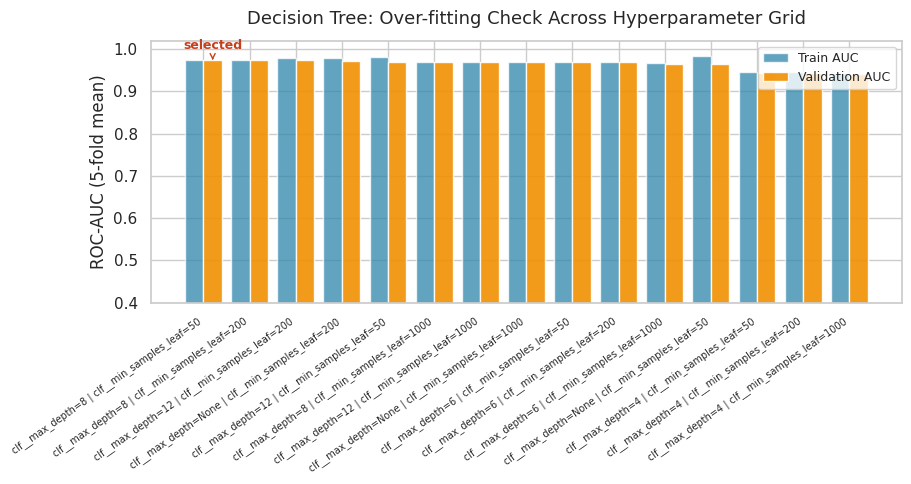

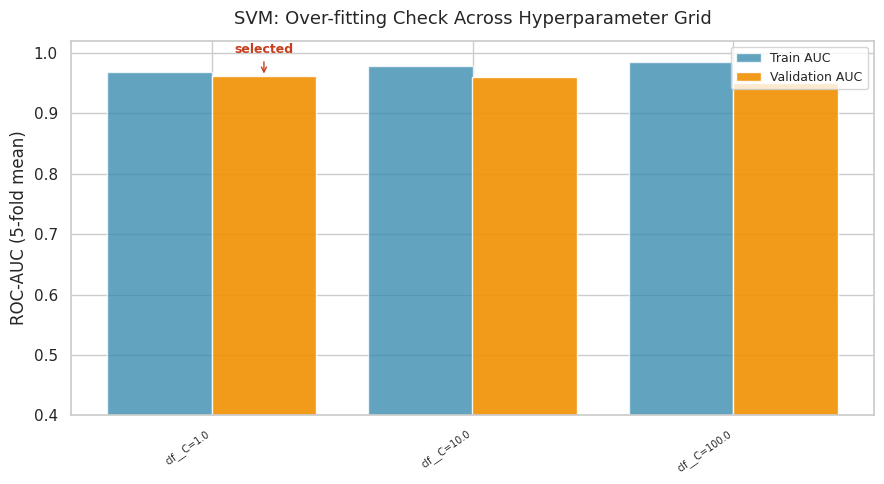

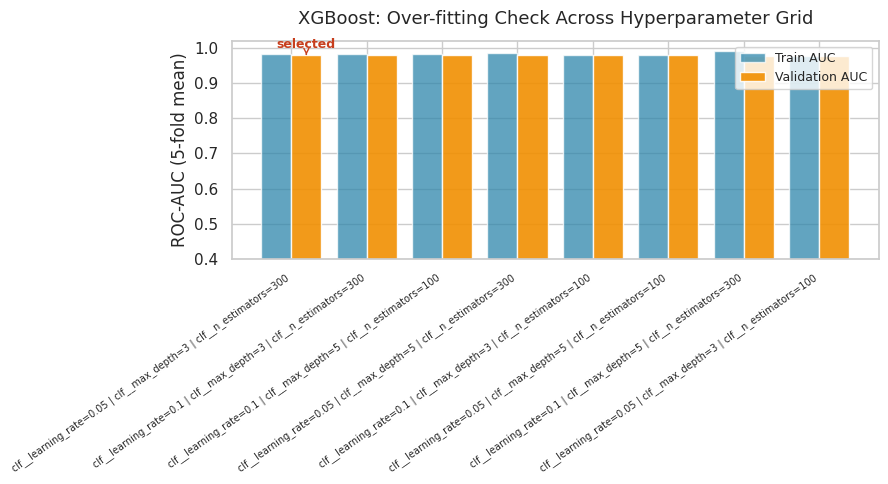

In [ ]:
for name, filename in [
    ("Logistic Regression", "cv_logistic.png"),
    ("Decision Tree", "cv_decision.png"),
    ("SVM", "cv_svm.png"),
    ("XGBoost", "cv_xgboost.png"),
]:
    plots.plot_cv_results(fitted[name].cv_results, name, filename)

In [ ]:
evals = [baseline_evaluation("Majority Baseline", splits.y_test)]
for name, model in fitted.items():
    evals.append(evaluate_pipeline(name, model.best_estimator,
                                   splits.X_test, splits.y_test))

table = metrics_table(evals)
table

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1-Score,TP,FP,TN,FN
Model,,,,,,,,,,
Majority Baseline,NaN,0.0882,0.9118,0.0000,0.0000,0.0000,0,0,13150,1272
Logistic Regression,0.9639,0.8314,0.8878,0.4336,0.8876,0.5826,1129,1475,11675,143
Decision Tree,0.9748,0.8647,0.8807,0.4204,0.9316,0.5793,1185,1634,11516,87
SVM,0.9619,0.7822,0.8960,0.4548,0.9009,0.6044,1146,1374,11776,126
XGBoost,0.9799,0.8923,0.9034,0.4756,0.9277,0.6288,1180,1301,11849,92


(<Axes: title={'center': 'Model Comparison on the Test Set'}, ylabel='Score'>,
 PosixPath('/content/ML_lab_project/figures/09_metric_comparison.png'))

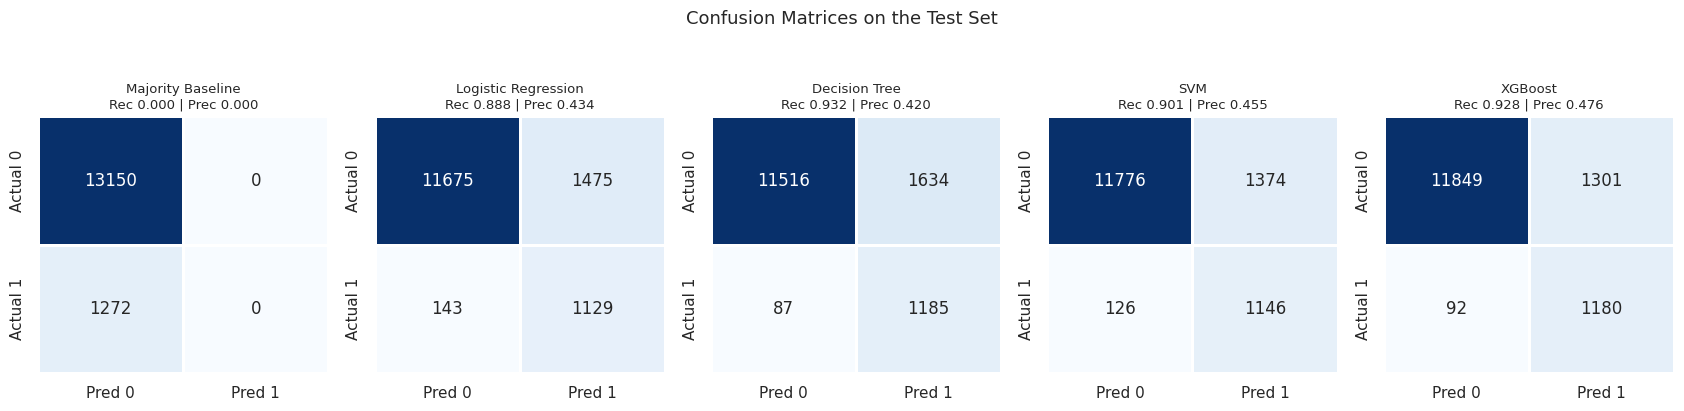

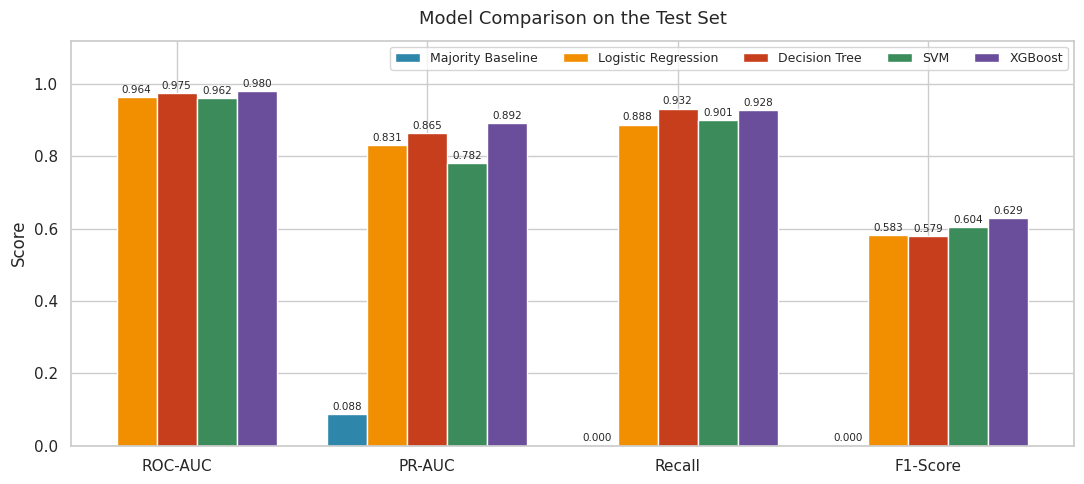

In [ ]:
plots.plot_confusion_matrices(evals)
plots.plot_metric_comparison(table)

(<Axes: title={'center': 'ROC Curves -- All Models on the Test Set'}, xlabel='False Positive Rate (1 - Specificity)', ylabel='True Positive Rate (Sensitivity)'>,
 PosixPath('/content/ML_lab_project/figures/06_roc_curves.png'))

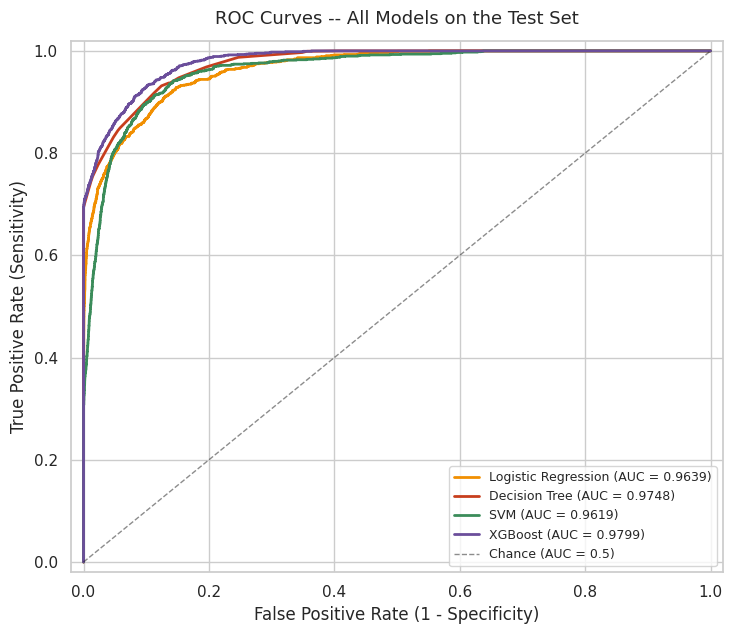

In [ ]:
plots.plot_roc_curves(evals)

(<Axes: title={'center': 'Precision-Recall Curves -- the right view for an 8.8% positive class'}, xlabel='Recall (Sensitivity)', ylabel='Precision (Positive Predictive Value)'>,
 PosixPath('/content/ML_lab_project/figures/07_precision_recall_curves.png'))

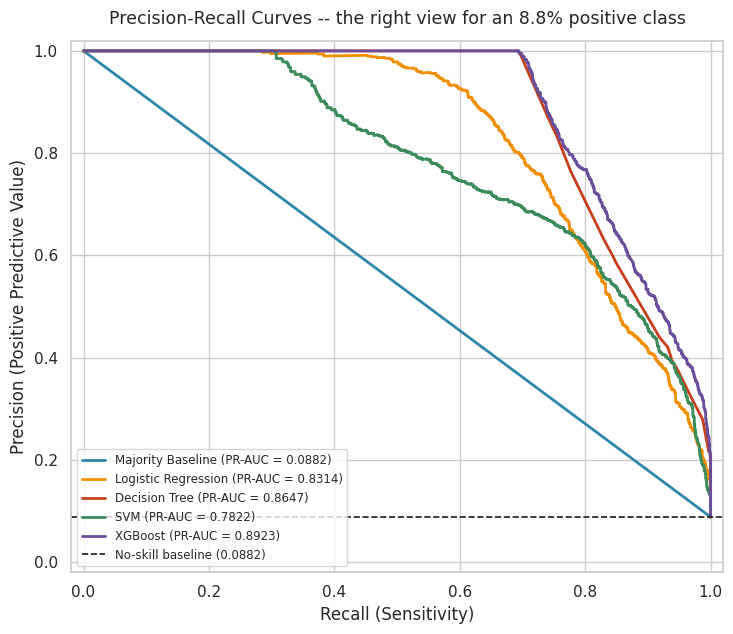

In [ ]:
plots.plot_pr_curves(evals, float(splits.y_test.mean()))

In [ ]:
result = final_result_table(evals)
result

,2. AUC,3. Accuracy,4. Precision,5. Recall,6. F1-Score
1. Model list,,,,,
Log St,0.9639,0.8878,0.4336,0.8876,0.5826
DT,0.9748,0.8807,0.4204,0.9316,0.5793
SVM,0.9619,0.8960,0.4548,0.9009,0.6044
XGBoost,0.9799,0.9034,0.4756,0.9277,0.6288


In [ ]:
print(baseline_reference_line(evals))

Majority-class baseline (always predict 'no diabetes'): Accuracy 0.9118, Recall 0.0000, PR-AUC 0.0882


,Feature,LogReg,Feature,Tree
0,HbA1c_level,0.3241,HbA1c_level,0.4945
1,blood_glucose_level,0.1871,blood_glucose_level,0.3530
2,age,0.1649,age,0.1166
3,smoking_history,0.1267,bmi,0.0316
4,bmi,0.0933,hypertension,0.0044
5,gender,0.0492,gender,0.0000
6,hypertension,0.0312,heart_disease,0.0000
7,heart_disease,0.0234,smoking_history,0.0000


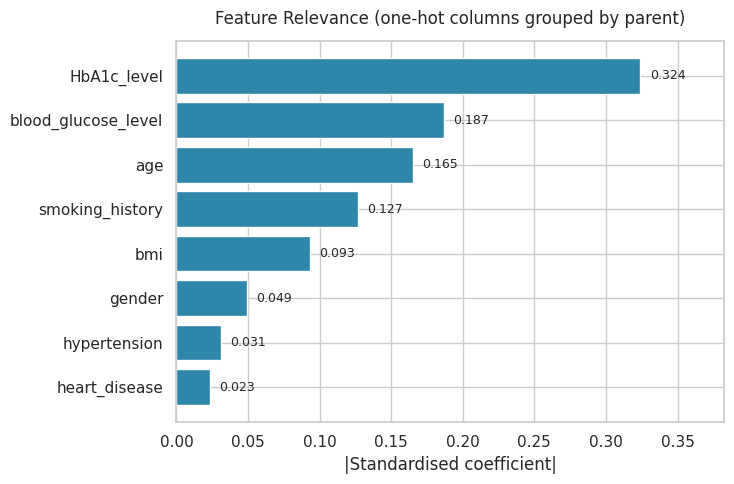

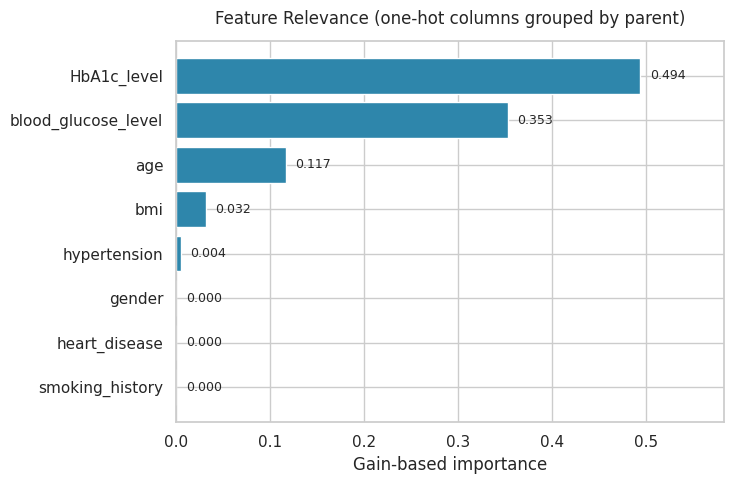

In [ ]:
imp_logreg = feature_importance(fitted["Logistic Regression"])
imp_tree = feature_importance(fitted["Decision Tree"])
plots.plot_feature_importance(
    imp_logreg, imp_logreg["Measure"].iloc[0],
    "10_feature_importance_logistic_regression.png")
plots.plot_feature_importance(
    imp_tree, imp_tree["Measure"].iloc[0],
    "11_feature_importance_decision_tree.png")

pd.concat([
    imp_logreg[["Feature", "Importance"]].rename(columns={"Importance": "LogReg"}),
    imp_tree[["Feature", "Importance"]].rename(columns={"Importance": "Tree"}),
], axis=1).round(4)